Añadimos el flag al predecir sobre el substet de test mixto --save probabilities para poder analizar las métricas de detección a lo largo de un umbral, analizando el área en las curvas Pr-sensibilidad o sensibilidad-FP/scan.

No se añadió este análisis a la memoria dado que la sensibilidad está muy acotada en todos los modelos, y no permite analizar un rango suficientemente amplio. Todas las áreas son mínimas, los modelos son muy conservadores.

### D201


--- Analizando Threshold: 0.01 ---


100%|██████████| 65/65 [02:35<00:00,  2.39s/it]


Resultados Globales (Thr 0.01):
TP: 121 | FN: 361 | FP: 27 (Total GT: 482)
Recall Micro: 0.2510 | Prec Micro: 0.8176 | FP/scan: 0.42

--- Analizando Threshold: 0.05 ---


100%|██████████| 65/65 [02:43<00:00,  2.51s/it]


Resultados Globales (Thr 0.05):
TP: 115 | FN: 367 | FP: 18 (Total GT: 482)
Recall Micro: 0.2386 | Prec Micro: 0.8647 | FP/scan: 0.28

--- Analizando Threshold: 0.1 ---


...

Resultados Globales (Thr 0.7):
TP: 105 | FN: 377 | FP: 12 (Total GT: 482)
Recall Micro: 0.2178 | Prec Micro: 0.8974 | FP/scan: 0.18

--- Analizando Threshold: 0.8 ---


100%|██████████| 65/65 [02:38<00:00,  2.45s/it]


Resultados Globales (Thr 0.8):
TP: 105 | FN: 377 | FP: 9 (Total GT: 482)
Recall Micro: 0.2178 | Prec Micro: 0.9211 | FP/scan: 0.14

--- Analizando Threshold: 0.9 ---


100%|██████████| 65/65 [02:43<00:00,  2.52s/it]


Resultados Globales (Thr 0.9):
TP: 104 | FN: 378 | FP: 8 (Total GT: 482)
Recall Micro: 0.2158 | Prec Micro: 0.9286 | FP/scan: 0.12

Análisis por umbrales guardado en: /media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/ANALYSIS_RESULTS_MIXTEST/D201_newspacing_PROB

--- Métricas de Curvas ---
AU-PR: 0.0306
Área bajo FROC (hasta FP max): 0.0682


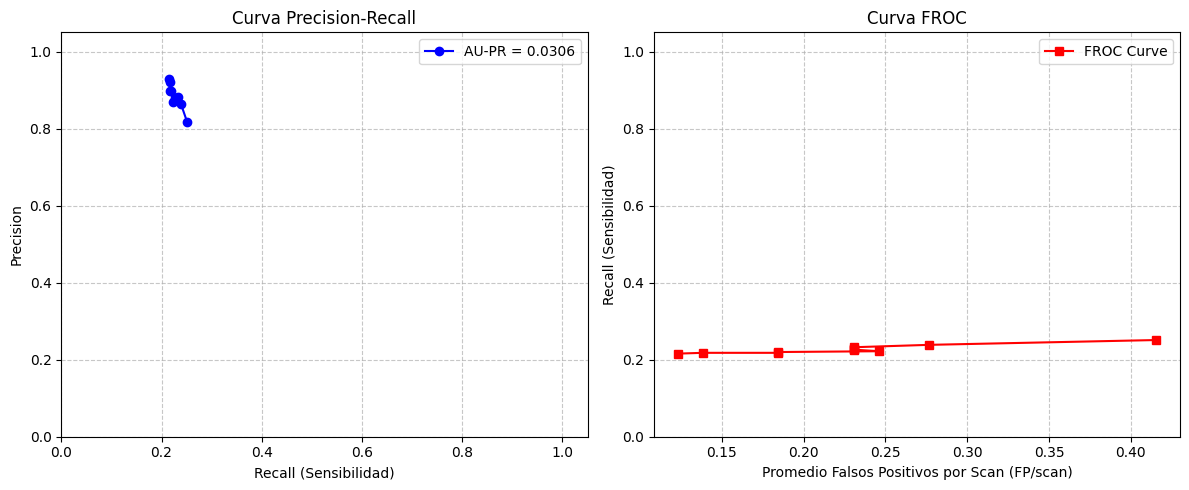


Gráficas guardadas


In [7]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from tqdm import tqdm
from skimage.measure import label

# =========================
# CONFIG
# =========================
PRED_FOLDER = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/predicts_from_201_newspacing"
GT_FOLDER = "/media/PORT-DISK/Practicas/nnUNet_raw_ADNI/Dataset205_MixCMB/labelsTs"
OUTPUT_PATH = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/ANALYSIS_RESULTS_MIXTEST/D201_newspacing_PROB"
os.makedirs(OUTPUT_PATH, exist_ok=True)

THRESHOLDS = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# =========================
# FUNCIONES
# =========================

def calculate_metrics(tp, fp, fn):
    """Calcula precision, recall y f1 de forma segura."""
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

def load_prob(npz_path):
    # nnU-Net guarda [canales, x, y, z]. El canal 1 suele ser la lesión.
    return np.load(npz_path)['probabilities'][1]

def match_blobs(gt_img, pred_mask):
    """
    Lógica basada en solapamiento:
    Un TP se cuenta si un blob de GT intersecta con al menos un voxel de la predicción.
    """
    labeled_gt, num_gt = label(gt_img > 0, return_num=True)
    labeled_pred, num_pred = label(pred_mask > 0, return_num=True)
    
    tp_count = 0
    used_pred_blobs = set()

    for gt_id in range(1, num_gt + 1):
        gt_blob_mask = (labeled_gt == gt_id)
        # Encontrar IDs de predicción que solapan con este blob de GT
        overlapping_pred_ids = np.unique(labeled_pred[gt_blob_mask])
        overlapping_pred_ids = overlapping_pred_ids[overlapping_pred_ids > 0]

        assigned = None
        for pid in overlapping_pred_ids:
            if pid not in used_pred_blobs:
                assigned = pid
                break
        
        if assigned is not None:
            tp_count += 1
            used_pred_blobs.add(assigned)

    fp_count = num_pred - len(used_pred_blobs)
    fn_count = num_gt - tp_count
    
    return tp_count, fp_count, fn_count

# =========================
# MAIN
# =========================

cases = sorted([f.replace(".npz", "") for f in os.listdir(PRED_FOLDER) if f.endswith(".npz")])
final_results = []

for thr in THRESHOLDS:
    print(f"\n--- Analizando Threshold: {thr} ---")
    
    subject_metrics = []
    
    for case in tqdm(cases):
        npz_path = os.path.join(PRED_FOLDER, f"{case}.npz")
        gt_path = os.path.join(GT_FOLDER, f"{case}.nii.gz")

        if not os.path.exists(gt_path):
            continue

        # Cargar datos
        prob = load_prob(npz_path)
        gt_nifti = nib.load(gt_path)
        gt_data = gt_nifti.get_fdata()
        
        # Binarizar predicción
        pred_mask = (prob > thr).astype(np.uint8)

        # Corregir transposición si las dimensiones no coinciden
        # (nnU-Net a veces exporta npz en ejes distintos al nifti original)
        if pred_mask.shape != gt_data.shape:
            pred_mask = np.transpose(pred_mask, (2, 1, 0))
            if pred_mask.shape != gt_data.shape:
                # Si sigue fallando, añadida por mí: intento de transposición alternativa
                pred_mask = np.transpose(prob, (1, 2, 0)) # Depende del preprocesado

        # Calcular matching por componentes conectadas
        tp, fp, fn = match_blobs(gt_data, pred_mask)
        
        # Métricas a nivel sujeto para este threshold
        prec, rec, f1 = calculate_metrics(tp, fp, fn)
        
        subject_metrics.append({
            'TP': tp, 'FP': fp, 'FN': fn,
            'Prec': prec, 'Rec': rec, 'F1': f1
        })

    # --- Agregación para el Threshold actual ---
    df_thr = pd.DataFrame(subject_metrics)
    
    # Micro (Suma de todo)
    total_tp = df_thr['TP'].sum()
    total_fp = df_thr['FP'].sum()
    total_fn = df_thr['FN'].sum()
    mi_prec, mi_rec, mi_f1 = calculate_metrics(total_tp, total_fp, total_fn)
    
    # Macro (Media de sujetos)
    ma_prec = df_thr['Prec'].mean()
    ma_rec = df_thr['Rec'].mean()
    ma_f1 = df_thr['F1'].mean()
    fp_per_scan = total_fp / len(cases)

    print(f"Resultados Globales (Thr {thr}):")
    print(f"TP: {total_tp} | FN: {total_fn} | FP: {total_fp} (Total GT: {total_tp + total_fn})")
    print(f"Recall Micro: {mi_rec:.4f} | Prec Micro: {mi_prec:.4f} | FP/scan: {fp_per_scan:.2f}")

    final_results.append({
        'threshold': thr,
        'TP_total': total_tp,
        'FP_total': total_fp,
        'FN_total': total_fn,
        'Recall_Micro': mi_rec,
        'Prec_Micro': mi_prec,
        'F1_Micro': mi_f1,
        'Recall_Macro': ma_rec,
        'Prec_Macro': ma_prec,
        'F1_Macro': ma_f1,
        'FP_per_scan': fp_per_scan
    })

# Guardar
df_final = pd.DataFrame(final_results)
df_final.to_csv(os.path.join(OUTPUT_PATH, "D201_newspacing_PROB_thrs.csv"), index=False)
print(f"\nAnálisis por umbrales guardado en: {OUTPUT_PATH}")

import matplotlib.pyplot as plt
from sklearn.metrics import auc

# =========================
# CÁLCULO DE MÉTRICAS GLOBALES
# =========================

# Extraer valores para las curvas
# Es importante que los datos estén ordenados por threshold para que las curvas sigan una lógica
df_final = df_final.sort_values('threshold', ascending=False)

thresholds = df_final['threshold'].values
recalls = df_final['Recall_Micro'].values
precisions = df_final['Prec_Micro'].values
fps_per_scan = df_final['FP_per_scan'].values

# 1. Calcular AU-PR (Área bajo Precision-Recall)
# Nota: Se suele añadir el punto (1, 0) y (0, 1) para cerrar la curva si es necesario
au_pr = auc(recalls, precisions)

# 2. Calcular "Área bajo la FROC" (opcional, en un rango específico de FP)
# El FROC no tiene un "área" estándar como el AUC-ROC, pero se puede calcular

### Daba ValueError: x is neither increasing nor decreasing
### Para solucionarlo, ordenamos puntos de fps_per_scan 

order = np.argsort(fps_per_scan)
fps_sorted = np.array(fps_per_scan)[order]
recalls_sorted = np.array(recalls)[order]

au_froc = auc(fps_sorted, recalls_sorted)

print(f"\n--- Métricas de Curvas ---")
print(f"AU-PR: {au_pr:.4f}")
print(f"Área bajo FROC (hasta FP max): {au_froc:.4f}")

# =========================
# GENERACIÓN DE GRÁFICAS
# =========================

plt.figure(figsize=(12, 5))

# --- Gráfica 1: Precision-Recall Curve ---
plt.subplot(1, 2, 1)
plt.plot(recalls, precisions, 'b-o', label=f'AU-PR = {au_pr:.4f}')
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.ylim([0, 1.05])
plt.xlim([0, 1.05])

# --- Gráfica 2: FROC Curve ---
plt.subplot(1, 2, 2)
plt.plot(fps_per_scan, recalls, 'r-s', label='FROC Curve')
plt.xlabel('Promedio Falsos Positivos por Scan (FP/scan)')
plt.ylabel('Recall (Sensibilidad)')
plt.title('Curva FROC')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
# El eje X en FROC suele dejarse abierto según el máximo de FP obtenido
plt.ylim([0, 1.05]) 

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "D201_newspacing_PROB_froc_curves.png"))
plt.show()

print("\nGráficas guardadas")

### D205


--- Analizando Threshold: 0.01 ---


100%|██████████| 65/65 [02:24<00:00,  2.23s/it]


Resultados Globales (Thr 0.01):
TP: 168 | FN: 314 | FP: 36 (Total GT: 482)
Recall Micro: 0.3485 | Prec Micro: 0.8235 | FP/scan: 0.55

--- Analizando Threshold: 0.05 ---


100%|██████████| 65/65 [02:41<00:00,  2.49s/it]


Resultados Globales (Thr 0.05):
TP: 158 | FN: 324 | FP: 26 (Total GT: 482)
Recall Micro: 0.3278 | Prec Micro: 0.8587 | FP/scan: 0.40

--- Analizando Threshold: 0.1 ---


...

Resultados Globales (Thr 0.7):
TP: 136 | FN: 346 | FP: 22 (Total GT: 482)
Recall Micro: 0.2822 | Prec Micro: 0.8608 | FP/scan: 0.34

--- Analizando Threshold: 0.8 ---


100%|██████████| 65/65 [02:35<00:00,  2.39s/it]


Resultados Globales (Thr 0.8):
TP: 135 | FN: 347 | FP: 22 (Total GT: 482)
Recall Micro: 0.2801 | Prec Micro: 0.8599 | FP/scan: 0.34

--- Analizando Threshold: 0.9 ---


100%|██████████| 65/65 [02:32<00:00,  2.35s/it]


Resultados Globales (Thr 0.9):
TP: 129 | FN: 353 | FP: 20 (Total GT: 482)
Recall Micro: 0.2676 | Prec Micro: 0.8658 | FP/scan: 0.31

Análisis por umbrales guardado en: /media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/ANALYSIS_RESULTS_MIXTEST/D205_newspacing_PROB

--- Métricas de Curvas ---
AU-PR: 0.0693
Área bajo FROC (hasta FP max): 0.0794


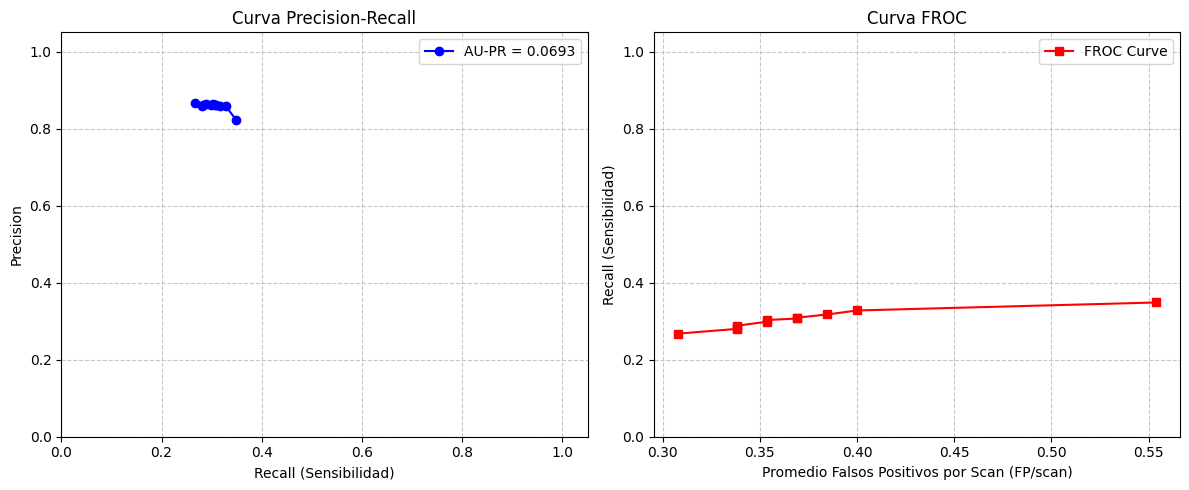


Gráficas guardadas


In [4]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from tqdm import tqdm
from skimage.measure import label

# =========================
# CONFIG
# =========================
PRED_FOLDER = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/predicts_from_205_newspacing"
GT_FOLDER = "/media/PORT-DISK/Practicas/nnUNet_raw_ADNI/Dataset205_MixCMB/labelsTs"
OUTPUT_PATH = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/ANALYSIS_RESULTS_MIXTEST/D205_newspacing_PROB"
os.makedirs(OUTPUT_PATH, exist_ok=True)

THRESHOLDS = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# =========================
# FUNCIONES
# =========================

def calculate_metrics(tp, fp, fn):
    """Calcula precision, recall y f1 de forma segura."""
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

def load_prob(npz_path):
    # nnU-Net guarda [canales, x, y, z]. El canal 1 suele ser la lesión.
    return np.load(npz_path)['probabilities'][1]

def match_blobs(gt_img, pred_mask):
    """
    Lógica basada en solapamiento:
    Un TP se cuenta si un blob de GT intersecta con al menos un voxel de la predicción.
    """
    labeled_gt, num_gt = label(gt_img > 0, return_num=True)
    labeled_pred, num_pred = label(pred_mask > 0, return_num=True)
    
    tp_count = 0
    used_pred_blobs = set()

    for gt_id in range(1, num_gt + 1):
        gt_blob_mask = (labeled_gt == gt_id)
        # Encontrar IDs de predicción que solapan con este blob de GT
        overlapping_pred_ids = np.unique(labeled_pred[gt_blob_mask])
        overlapping_pred_ids = overlapping_pred_ids[overlapping_pred_ids > 0]

        assigned = None
        for pid in overlapping_pred_ids:
            if pid not in used_pred_blobs:
                assigned = pid
                break
        
        if assigned is not None:
            tp_count += 1
            used_pred_blobs.add(assigned)

    fp_count = num_pred - len(used_pred_blobs)
    fn_count = num_gt - tp_count
    
    return tp_count, fp_count, fn_count

# =========================
# MAIN
# =========================

cases = sorted([f.replace(".npz", "") for f in os.listdir(PRED_FOLDER) if f.endswith(".npz")])
final_results = []

for thr in THRESHOLDS:
    print(f"\n--- Analizando Threshold: {thr} ---")
    
    subject_metrics = []
    
    for case in tqdm(cases):
        npz_path = os.path.join(PRED_FOLDER, f"{case}.npz")
        gt_path = os.path.join(GT_FOLDER, f"{case}.nii.gz")

        if not os.path.exists(gt_path):
            continue

        # Cargar datos
        prob = load_prob(npz_path)
        gt_nifti = nib.load(gt_path)
        gt_data = gt_nifti.get_fdata()
        
        # Binarizar predicción
        pred_mask = (prob > thr).astype(np.uint8)

        # Corregir transposición si las dimensiones no coinciden
        # (nnU-Net a veces exporta npz en ejes distintos al nifti original)
        if pred_mask.shape != gt_data.shape:
            pred_mask = np.transpose(pred_mask, (2, 1, 0))
            if pred_mask.shape != gt_data.shape:
                # Si sigue fallando, añadida por mí: intento de transposición alternativa
                pred_mask = np.transpose(prob, (1, 2, 0)) # Depende del preprocesado

        # Calcular matching por componentes conectadas
        tp, fp, fn = match_blobs(gt_data, pred_mask)
        
        # Métricas a nivel sujeto para este threshold
        prec, rec, f1 = calculate_metrics(tp, fp, fn)
        
        subject_metrics.append({
            'TP': tp, 'FP': fp, 'FN': fn,
            'Prec': prec, 'Rec': rec, 'F1': f1
        })

    # --- Agregación para el Threshold actual ---
    df_thr = pd.DataFrame(subject_metrics)
    
    # Micro (Suma de todo)
    total_tp = df_thr['TP'].sum()
    total_fp = df_thr['FP'].sum()
    total_fn = df_thr['FN'].sum()
    mi_prec, mi_rec, mi_f1 = calculate_metrics(total_tp, total_fp, total_fn)
    
    # Macro (Media de sujetos)
    ma_prec = df_thr['Prec'].mean()
    ma_rec = df_thr['Rec'].mean()
    ma_f1 = df_thr['F1'].mean()
    fp_per_scan = total_fp / len(cases)

    print(f"Resultados Globales (Thr {thr}):")
    print(f"TP: {total_tp} | FN: {total_fn} | FP: {total_fp} (Total GT: {total_tp + total_fn})")
    print(f"Recall Micro: {mi_rec:.4f} | Prec Micro: {mi_prec:.4f} | FP/scan: {fp_per_scan:.2f}")

    final_results.append({
        'threshold': thr,
        'TP_total': total_tp,
        'FP_total': total_fp,
        'FN_total': total_fn,
        'Recall_Micro': mi_rec,
        'Prec_Micro': mi_prec,
        'F1_Micro': mi_f1,
        'Recall_Macro': ma_rec,
        'Prec_Macro': ma_prec,
        'F1_Macro': ma_f1,
        'FP_per_scan': fp_per_scan
    })

# Guardar
df_final = pd.DataFrame(final_results)
df_final.to_csv(os.path.join(OUTPUT_PATH, "D205_newspacing_PROB_thrs.csv"), index=False)
print(f"\nAnálisis por umbrales guardado en: {OUTPUT_PATH}")

import matplotlib.pyplot as plt
from sklearn.metrics import auc

# =========================
# CÁLCULO DE MÉTRICAS GLOBALES
# =========================

# Extraer valores para las curvas
# Es importante que los datos estén ordenados por threshold para que las curvas sigan una lógica
df_final = df_final.sort_values('threshold', ascending=False)

thresholds = df_final['threshold'].values
recalls = df_final['Recall_Micro'].values
precisions = df_final['Prec_Micro'].values
fps_per_scan = df_final['FP_per_scan'].values

# 1. Calcular AU-PR (Área bajo Precision-Recall)
# Nota: Se suele añadir el punto (1, 0) y (0, 1) para cerrar la curva si es necesario
au_pr = auc(recalls, precisions)

# 2. Calcular "Área bajo la FROC" (opcional, en un rango específico de FP)
# El FROC no tiene un "área" estándar como el AUC-ROC, pero se puede calcular
au_froc = auc(fps_per_scan, recalls)

print(f"\n--- Métricas de Curvas ---")
print(f"AU-PR: {au_pr:.4f}")
print(f"Área bajo FROC (hasta FP max): {au_froc:.4f}")

# =========================
# GENERACIÓN DE GRÁFICAS
# =========================

plt.figure(figsize=(12, 5))

# --- Gráfica 1: Precision-Recall Curve ---
plt.subplot(1, 2, 1)
plt.plot(recalls, precisions, 'b-o', label=f'AU-PR = {au_pr:.4f}')
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.ylim([0, 1.05])
plt.xlim([0, 1.05])

# --- Gráfica 2: FROC Curve ---
plt.subplot(1, 2, 2)
plt.plot(fps_per_scan, recalls, 'r-s', label='FROC Curve')
plt.xlabel('Promedio Falsos Positivos por Scan (FP/scan)')
plt.ylabel('Recall (Sensibilidad)')
plt.title('Curva FROC')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
# El eje X en FROC suele dejarse abierto según el máximo de FP obtenido
plt.ylim([0, 1.05]) 

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "D205_newspacing_PROB_froc_curves.png"))
plt.show()

print("\nGráficas guardadas")

### D207


--- Analizando Threshold: 0.01 ---


100%|██████████| 65/65 [02:39<00:00,  2.45s/it]


Resultados Globales (Thr 0.01):
TP: 279 | FN: 203 | FP: 103 (Total GT: 482)
Recall Micro: 0.5788 | Prec Micro: 0.7304 | FP/scan: 1.58

--- Analizando Threshold: 0.05 ---


100%|██████████| 65/65 [02:39<00:00,  2.46s/it]


Resultados Globales (Thr 0.05):
TP: 271 | FN: 211 | FP: 88 (Total GT: 482)
Recall Micro: 0.5622 | Prec Micro: 0.7549 | FP/scan: 1.35

--- Analizando Threshold: 0.1 ---


...

Resultados Globales (Thr 0.7):
TP: 257 | FN: 225 | FP: 60 (Total GT: 482)
Recall Micro: 0.5332 | Prec Micro: 0.8107 | FP/scan: 0.92

--- Analizando Threshold: 0.8 ---


100%|██████████| 65/65 [02:38<00:00,  2.44s/it]


Resultados Globales (Thr 0.8):
TP: 253 | FN: 229 | FP: 56 (Total GT: 482)
Recall Micro: 0.5249 | Prec Micro: 0.8188 | FP/scan: 0.86

--- Analizando Threshold: 0.9 ---


100%|██████████| 65/65 [02:38<00:00,  2.45s/it]


Resultados Globales (Thr 0.9):
TP: 248 | FN: 234 | FP: 54 (Total GT: 482)
Recall Micro: 0.5145 | Prec Micro: 0.8212 | FP/scan: 0.83

Análisis por umbrales guardado en: /media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/ANALYSIS_RESULTS_MIXTEST/D207_newspacing_PROB_corrected

--- Métricas de Curvas ---
AU-PR: 0.0498
Área bajo FROC (hasta FP max): 0.4129


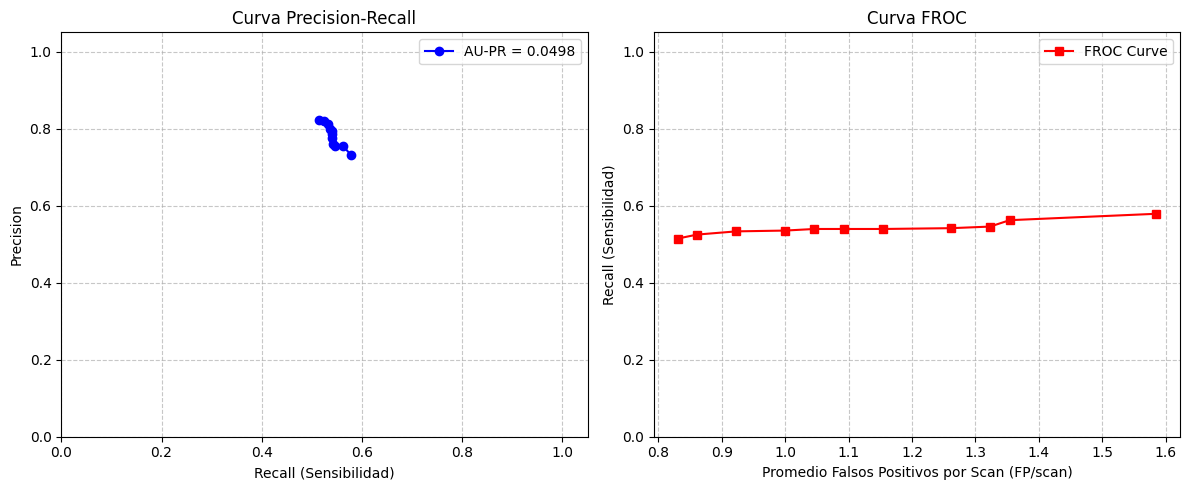


Gráficas guardadas


In [1]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from tqdm import tqdm
from skimage.measure import label

# =========================
# CONFIG
# =========================
PRED_FOLDER = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/predicts_from_207_PROB_corrected"
GT_FOLDER = "/media/PORT-DISK/Practicas/nnUNet_raw_ADNI/Dataset205_MixCMB/labelsTs"
OUTPUT_PATH = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/ANALYSIS_RESULTS_MIXTEST/D207_newspacing_PROB_corrected"
os.makedirs(OUTPUT_PATH, exist_ok=True)

THRESHOLDS = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# =========================
# FUNCIONES
# =========================

def calculate_metrics(tp, fp, fn):
    """Calcula precision, recall y f1 de forma segura."""
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

def load_prob(npz_path):
    # nnU-Net guarda [canales, x, y, z]. El canal 1 suele ser la lesión.
    return np.load(npz_path)['probabilities'][1]

def match_blobs(gt_img, pred_mask):
    """
    Lógica basada en solapamiento:
    Un TP se cuenta si un blob de GT intersecta con al menos un voxel de la predicción.
    """
    labeled_gt, num_gt = label(gt_img > 0, return_num=True)
    labeled_pred, num_pred = label(pred_mask > 0, return_num=True)
    
    tp_count = 0
    used_pred_blobs = set()

    for gt_id in range(1, num_gt + 1):
        gt_blob_mask = (labeled_gt == gt_id)
        # Encontrar IDs de predicción que solapan con este blob de GT
        overlapping_pred_ids = np.unique(labeled_pred[gt_blob_mask])
        overlapping_pred_ids = overlapping_pred_ids[overlapping_pred_ids > 0]

        assigned = None
        for pid in overlapping_pred_ids:
            if pid not in used_pred_blobs:
                assigned = pid
                break
        
        if assigned is not None:
            tp_count += 1
            used_pred_blobs.add(assigned)

    fp_count = num_pred - len(used_pred_blobs)
    fn_count = num_gt - tp_count
    
    return tp_count, fp_count, fn_count

# =========================
# MAIN
# =========================

cases = sorted([f.replace(".npz", "") for f in os.listdir(PRED_FOLDER) if f.endswith(".npz")])
final_results = []

for thr in THRESHOLDS:
    print(f"\n--- Analizando Threshold: {thr} ---")
    
    subject_metrics = []
    
    for case in tqdm(cases):
        npz_path = os.path.join(PRED_FOLDER, f"{case}.npz")
        gt_path = os.path.join(GT_FOLDER, f"{case}.nii.gz")

        if not os.path.exists(gt_path):
            continue

        # Cargar datos
        prob = load_prob(npz_path)
        gt_nifti = nib.load(gt_path)
        gt_data = gt_nifti.get_fdata()
        
        # Binarizar predicción
        pred_mask = (prob > thr).astype(np.uint8)

        # Corregir transposición si las dimensiones no coinciden
        # (nnU-Net a veces exporta npz en ejes distintos al nifti original)
        if pred_mask.shape != gt_data.shape:
            pred_mask = np.transpose(pred_mask, (2, 1, 0))
            if pred_mask.shape != gt_data.shape:
                # Si sigue fallando, añadida por mí: intento de transposición alternativa
                pred_mask = np.transpose(prob, (1, 2, 0)) # Depende del preprocesado

        # Calcular matching por componentes conectadas
        tp, fp, fn = match_blobs(gt_data, pred_mask)
        
        # Métricas a nivel sujeto para este threshold
        prec, rec, f1 = calculate_metrics(tp, fp, fn)
        
        subject_metrics.append({
            'TP': tp, 'FP': fp, 'FN': fn,
            'Prec': prec, 'Rec': rec, 'F1': f1
        })

    # --- Agregación para el Threshold actual ---
    df_thr = pd.DataFrame(subject_metrics)
    
    # Micro (Suma de todo)
    total_tp = df_thr['TP'].sum()
    total_fp = df_thr['FP'].sum()
    total_fn = df_thr['FN'].sum()
    mi_prec, mi_rec, mi_f1 = calculate_metrics(total_tp, total_fp, total_fn)
    
    # Macro (Media de sujetos)
    ma_prec = df_thr['Prec'].mean()
    ma_rec = df_thr['Rec'].mean()
    ma_f1 = df_thr['F1'].mean()
    fp_per_scan = total_fp / len(cases)

    print(f"Resultados Globales (Thr {thr}):")
    print(f"TP: {total_tp} | FN: {total_fn} | FP: {total_fp} (Total GT: {total_tp + total_fn})")
    print(f"Recall Micro: {mi_rec:.4f} | Prec Micro: {mi_prec:.4f} | FP/scan: {fp_per_scan:.2f}")

    final_results.append({
        'threshold': thr,
        'TP_total': total_tp,
        'FP_total': total_fp,
        'FN_total': total_fn,
        'Recall_Micro': mi_rec,
        'Prec_Micro': mi_prec,
        'F1_Micro': mi_f1,
        'Recall_Macro': ma_rec,
        'Prec_Macro': ma_prec,
        'F1_Macro': ma_f1,
        'FP_per_scan': fp_per_scan
    })

# Guardar
df_final = pd.DataFrame(final_results)
df_final.to_csv(os.path.join(OUTPUT_PATH, "D207_newspacing_PROB_thrs.csv"), index=False)
print(f"\nAnálisis por umbrales guardado en: {OUTPUT_PATH}")

import matplotlib.pyplot as plt
from sklearn.metrics import auc

# =========================
# CÁLCULO DE MÉTRICAS GLOBALES
# =========================

# Extraer valores para las curvas
# Es importante que los datos estén ordenados por threshold para que las curvas sigan una lógica
df_final = df_final.sort_values('threshold', ascending=False)

thresholds = df_final['threshold'].values
recalls = df_final['Recall_Micro'].values
precisions = df_final['Prec_Micro'].values
fps_per_scan = df_final['FP_per_scan'].values

# 1. Calcular AU-PR (Área bajo Precision-Recall)
# Nota: Se suele añadir el punto (1, 0) y (0, 1) para cerrar la curva si es necesario
au_pr = auc(recalls, precisions)

# 2. Calcular "Área bajo la FROC" (opcional, en un rango específico de FP)
# El FROC no tiene un "área" estándar como el AUC-ROC, pero se puede calcular

order = np.argsort(fps_per_scan)
fps_sorted = np.array(fps_per_scan)[order]
recalls_sorted = np.array(recalls)[order]

au_froc = auc(fps_sorted, recalls_sorted)

print(f"\n--- Métricas de Curvas ---")
print(f"AU-PR: {au_pr:.4f}")
print(f"Área bajo FROC (hasta FP max): {au_froc:.4f}")

# =========================
# GENERACIÓN DE GRÁFICAS
# =========================

plt.figure(figsize=(12, 5))

# --- Gráfica 1: Precision-Recall Curve ---
plt.subplot(1, 2, 1)
plt.plot(recalls, precisions, 'b-o', label=f'AU-PR = {au_pr:.4f}')
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.ylim([0, 1.05])
plt.xlim([0, 1.05])

# --- Gráfica 2: FROC Curve ---
plt.subplot(1, 2, 2)
plt.plot(fps_per_scan, recalls, 'r-s', label='FROC Curve')
plt.xlabel('Promedio Falsos Positivos por Scan (FP/scan)')
plt.ylabel('Recall (Sensibilidad)')
plt.title('Curva FROC')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
# El eje X en FROC suele dejarse abierto según el máximo de FP obtenido
plt.ylim([0, 1.05]) 

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "D207_newspacing_PROB_froc_curves.png"))
plt.show()

print("\nGráficas guardadas")

### D208


--- Analizando Threshold: 0.01 ---


100%|██████████| 65/65 [02:37<00:00,  2.42s/it]


Resultados Globales (Thr 0.01):
TP: 313 | FN: 169 | FP: 202 (Total GT: 482)
Recall Micro: 0.6494 | Prec Micro: 0.6078 | F1 Micro: 0.6279 | FP/scan: 3.11

--- Analizando Threshold: 0.05 ---


100%|██████████| 65/65 [02:36<00:00,  2.41s/it]


Resultados Globales (Thr 0.05):
TP: 308 | FN: 174 | FP: 160 (Total GT: 482)
Recall Micro: 0.6390 | Prec Micro: 0.6581 | F1 Micro: 0.6484 | FP/scan: 2.46

--- Analizando Threshold: 0.1 ---


...

Resultados Globales (Thr 0.7):
TP: 283 | FN: 199 | FP: 103 (Total GT: 482)
Recall Micro: 0.5871 | Prec Micro: 0.7332 | F1 Micro: 0.6521 | FP/scan: 1.58

--- Analizando Threshold: 0.8 ---


100%|██████████| 65/65 [02:42<00:00,  2.50s/it]


Resultados Globales (Thr 0.8):
TP: 281 | FN: 201 | FP: 97 (Total GT: 482)
Recall Micro: 0.5830 | Prec Micro: 0.7434 | F1 Micro: 0.6535 | FP/scan: 1.49

--- Analizando Threshold: 0.9 ---


100%|██████████| 65/65 [02:41<00:00,  2.49s/it]


Resultados Globales (Thr 0.9):
TP: 275 | FN: 207 | FP: 93 (Total GT: 482)
Recall Micro: 0.5705 | Prec Micro: 0.7473 | F1 Micro: 0.6471 | FP/scan: 1.43

Análisis por umbrales guardado en: /media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/ANALYSIS_RESULTS_MIXTEST/D208_newspacing_PROB_corrected

--- Métricas de Curvas ---
AU-PR: 0.0554
Área bajo FROC (hasta FP max): 1.0479


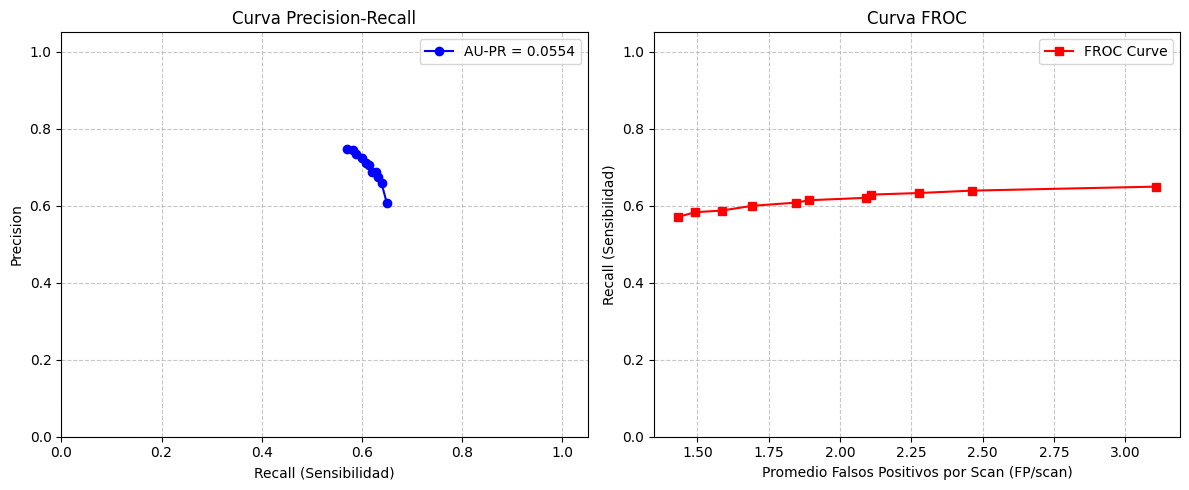


Gráficas guardadas


In [1]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from tqdm import tqdm
from skimage.measure import label

# =========================
# CONFIG
# =========================
PRED_FOLDER = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/predicts_from_208_PROB_corrected"
GT_FOLDER = "/media/PORT-DISK/Practicas/nnUNet_raw_ADNI/Dataset205_MixCMB/labelsTs"
OUTPUT_PATH = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/ANALYSIS_RESULTS_MIXTEST/D208_newspacing_PROB_corrected"
os.makedirs(OUTPUT_PATH, exist_ok=True)

THRESHOLDS = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# =========================
# FUNCIONES
# =========================

def calculate_metrics(tp, fp, fn):
    """Calcula precision, recall y f1 de forma segura."""
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

def load_prob(npz_path):
    # nnU-Net guarda [canales, x, y, z]. El canal 1 suele ser la lesión.
    return np.load(npz_path)['probabilities'][1]

def match_blobs(gt_img, pred_mask):
    """
    Lógica basada en solapamiento:
    Un TP se cuenta si un blob de GT intersecta con al menos un voxel de la predicción.
    """
    labeled_gt, num_gt = label(gt_img > 0, return_num=True)
    labeled_pred, num_pred = label(pred_mask > 0, return_num=True)
    
    tp_count = 0
    used_pred_blobs = set()

    for gt_id in range(1, num_gt + 1):
        gt_blob_mask = (labeled_gt == gt_id)
        # Encontrar IDs de predicción que solapan con este blob de GT
        overlapping_pred_ids = np.unique(labeled_pred[gt_blob_mask])
        overlapping_pred_ids = overlapping_pred_ids[overlapping_pred_ids > 0]

        assigned = None
        for pid in overlapping_pred_ids:
            if pid not in used_pred_blobs:
                assigned = pid
                break
        
        if assigned is not None:
            tp_count += 1
            used_pred_blobs.add(assigned)

    fp_count = num_pred - len(used_pred_blobs)
    fn_count = num_gt - tp_count
    
    return tp_count, fp_count, fn_count

# =========================
# MAIN
# =========================

cases = sorted([f.replace(".npz", "") for f in os.listdir(PRED_FOLDER) if f.endswith(".npz")])
final_results = []

for thr in THRESHOLDS:
    print(f"\n--- Analizando Threshold: {thr} ---")
    
    subject_metrics = []
    
    for case in tqdm(cases):
        npz_path = os.path.join(PRED_FOLDER, f"{case}.npz")
        gt_path = os.path.join(GT_FOLDER, f"{case}.nii.gz")

        if not os.path.exists(gt_path):
            continue

        # Cargar datos
        prob = load_prob(npz_path)
        gt_nifti = nib.load(gt_path)
        gt_data = gt_nifti.get_fdata()
        
        # Binarizar predicción
        pred_mask = (prob > thr).astype(np.uint8)

        # Corregir transposición si las dimensiones no coinciden
        # (nnU-Net a veces exporta npz en ejes distintos al nifti original)
        if pred_mask.shape != gt_data.shape:
            pred_mask = np.transpose(pred_mask, (2, 1, 0))
            if pred_mask.shape != gt_data.shape:
                # Si sigue fallando, añadida por mí: intento de transposición alternativa
                pred_mask = np.transpose(prob, (1, 2, 0)) # Depende del preprocesado

        # Calcular matching por componentes conectadas
        tp, fp, fn = match_blobs(gt_data, pred_mask)
        
        # Métricas a nivel sujeto para este threshold
        prec, rec, f1 = calculate_metrics(tp, fp, fn)
        
        subject_metrics.append({
            'TP': tp, 'FP': fp, 'FN': fn,
            'Prec': prec, 'Rec': rec, 'F1': f1
        })

    # --- Agregación para el Threshold actual ---
    df_thr = pd.DataFrame(subject_metrics)
    
    # Micro (Suma de todo)
    total_tp = df_thr['TP'].sum()
    total_fp = df_thr['FP'].sum()
    total_fn = df_thr['FN'].sum()
    mi_prec, mi_rec, mi_f1 = calculate_metrics(total_tp, total_fp, total_fn)
    
    # Macro (Media de sujetos)
    ma_prec = df_thr['Prec'].mean()
    ma_rec = df_thr['Rec'].mean()
    ma_f1 = df_thr['F1'].mean()
    fp_per_scan = total_fp / len(cases)

    print(f"Resultados Globales (Thr {thr}):")
    print(f"TP: {total_tp} | FN: {total_fn} | FP: {total_fp} (Total GT: {total_tp + total_fn})")
    print(f"Recall Micro: {mi_rec:.4f} | Prec Micro: {mi_prec:.4f} | F1 Micro: {mi_f1:.4f} | FP/scan: {fp_per_scan:.2f}")

    final_results.append({
        'threshold': thr,
        'TP_total': total_tp,
        'FP_total': total_fp,
        'FN_total': total_fn,
        'Recall_Micro': mi_rec,
        'Prec_Micro': mi_prec,
        'F1_Micro': mi_f1,
        'Recall_Macro': ma_rec,
        'Prec_Macro': ma_prec,
        'F1_Macro': ma_f1,
        'FP_per_scan': fp_per_scan
    })

# Guardar
df_final = pd.DataFrame(final_results)
df_final.to_csv(os.path.join(OUTPUT_PATH, "D208_newspacing_PROB_thrs.csv"), index=False)
print(f"\nAnálisis por umbrales guardado en: {OUTPUT_PATH}")

import matplotlib.pyplot as plt
from sklearn.metrics import auc

# =========================
# CÁLCULO DE MÉTRICAS GLOBALES
# =========================

# Extraer valores para las curvas
# Es importante que los datos estén ordenados por threshold para que las curvas sigan una lógica
df_final = df_final.sort_values('threshold', ascending=False)

thresholds = df_final['threshold'].values
recalls = df_final['Recall_Micro'].values
precisions = df_final['Prec_Micro'].values
fps_per_scan = df_final['FP_per_scan'].values

# 1. Calcular AU-PR (Área bajo Precision-Recall)
# Nota: Se suele añadir el punto (1, 0) y (0, 1) para cerrar la curva si es necesario

# lo mismo que abajo!! ordenar para evitar el value error por falta de monotonía
order = np.argsort(recalls)
recalls_sorted = np.array(recalls)[order]
precisions_sorted = np.array(precisions)[order]

au_pr = auc(recalls_sorted, precisions_sorted)

# 2. Calcular "Área bajo la FROC" (opcional, en un rango específico de FP)
# El FROC no tiene un "área" estándar como el AUC-ROC, pero se puede calcular

order = np.argsort(fps_per_scan)
fps_sorted = np.array(fps_per_scan)[order]
#recalls_sorted = np.array(recalls)[order] Ya hecho arriba

au_froc = auc(fps_sorted, recalls_sorted)

print(f"\n--- Métricas de Curvas ---")
print(f"AU-PR: {au_pr:.4f}")
print(f"Área bajo FROC (hasta FP max): {au_froc:.4f}")

# =========================
# GENERACIÓN DE GRÁFICAS
# =========================

plt.figure(figsize=(12, 5))

# --- Gráfica 1: Precision-Recall Curve ---
plt.subplot(1, 2, 1)
plt.plot(recalls, precisions, 'b-o', label=f'AU-PR = {au_pr:.4f}')
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.ylim([0, 1.05])
plt.xlim([0, 1.05])

# --- Gráfica 2: FROC Curve ---
plt.subplot(1, 2, 2)
plt.plot(fps_per_scan, recalls, 'r-s', label='FROC Curve')
plt.xlabel('Promedio Falsos Positivos por Scan (FP/scan)')
plt.ylabel('Recall (Sensibilidad)')
plt.title('Curva FROC')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
# El eje X en FROC suele dejarse abierto según el máximo de FP obtenido
plt.ylim([0, 1.05]) 

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "D208_newspacing_PROB_froc_curves.png"))
plt.show()

print("\nGráficas guardadas")

### D800


--- Analizando Threshold: 0.01 ---


100%|██████████| 65/65 [02:16<00:00,  2.10s/it]


Resultados Globales (Thr 0.01):
TP: 201 | FN: 281 (Total GT: 482)
Recall Micro: 0.4170 | Prec Micro: 0.4891 | FP/scan: 3.23

--- Analizando Threshold: 0.05 ---


100%|██████████| 65/65 [02:16<00:00,  2.09s/it]


Resultados Globales (Thr 0.05):
TP: 195 | FN: 287 (Total GT: 482)
Recall Micro: 0.4046 | Prec Micro: 0.5402 | FP/scan: 2.55

--- Analizando Threshold: 0.1 ---


...

Resultados Globales (Thr 0.7):
TP: 183 | FN: 299 (Total GT: 482)
Recall Micro: 0.3797 | Prec Micro: 0.6080 | FP/scan: 1.82

--- Analizando Threshold: 0.8 ---


100%|██████████| 65/65 [02:25<00:00,  2.25s/it]


Resultados Globales (Thr 0.8):
TP: 182 | FN: 300 (Total GT: 482)
Recall Micro: 0.3776 | Prec Micro: 0.6190 | FP/scan: 1.72

--- Analizando Threshold: 0.9 ---


100%|██████████| 65/65 [02:30<00:00,  2.32s/it]


Resultados Globales (Thr 0.9):
TP: 179 | FN: 303 (Total GT: 482)
Recall Micro: 0.3714 | Prec Micro: 0.6303 | FP/scan: 1.62

Análisis por umbrales guardado en: /media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/ANALYSIS_RESULTS_MIXTEST/D800_PROB

--- Métricas de Curvas ---
AU-PR: 0.0261
Área bajo FROC (hasta FP max): 0.6451


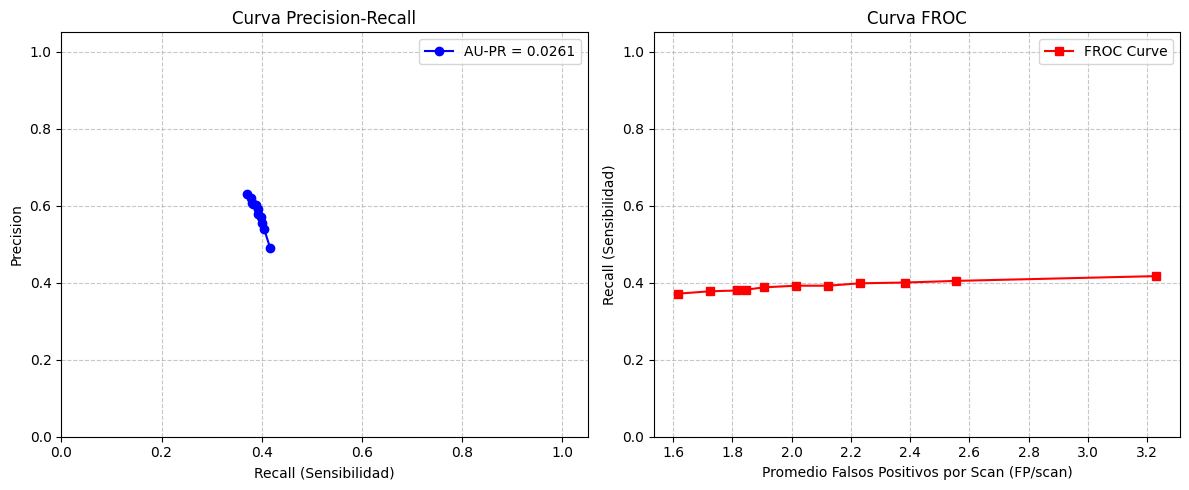


Gráficas guardadas


In [3]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from tqdm import tqdm
from skimage.measure import label

# =========================
# CONFIG
# =========================
PRED_FOLDER = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/predicts_from_800_PROB"
GT_FOLDER = "/media/PORT-DISK/Practicas/nnUNet_raw_ADNI/Dataset205_MixCMB/labelsTs"
OUTPUT_PATH = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/ANALYSIS_RESULTS_MIXTEST/D800_PROB"
os.makedirs(OUTPUT_PATH, exist_ok=True)

THRESHOLDS = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# =========================
# FUNCIONES
# =========================

def calculate_metrics(tp, fp, fn):
    """Calcula precision, recall y f1 de forma segura."""
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

def load_prob(npz_path):
    # nnU-Net guarda [canales, x, y, z]. El canal 1 suele ser la lesión.
    return np.load(npz_path)['probabilities'][1]

def match_blobs(gt_img, pred_mask):
    """
    Lógica basada en solapamiento:
    Un TP se cuenta si un blob de GT intersecta con al menos un voxel de la predicción.
    """
    labeled_gt, num_gt = label(gt_img > 0, return_num=True)
    labeled_pred, num_pred = label(pred_mask > 0, return_num=True)
    
    tp_count = 0
    used_pred_blobs = set()

    for gt_id in range(1, num_gt + 1):
        gt_blob_mask = (labeled_gt == gt_id)
        # Encontrar IDs de predicción que solapan con este blob de GT
        overlapping_pred_ids = np.unique(labeled_pred[gt_blob_mask])
        overlapping_pred_ids = overlapping_pred_ids[overlapping_pred_ids > 0]

        assigned = None
        for pid in overlapping_pred_ids:
            if pid not in used_pred_blobs:
                assigned = pid
                break
        
        if assigned is not None:
            tp_count += 1
            used_pred_blobs.add(assigned)

    fp_count = num_pred - len(used_pred_blobs)
    fn_count = num_gt - tp_count
    
    return tp_count, fp_count, fn_count

# =========================
# MAIN
# =========================

cases = sorted([f.replace(".npz", "") for f in os.listdir(PRED_FOLDER) if f.endswith(".npz")])
final_results = []

for thr in THRESHOLDS:
    print(f"\n--- Analizando Threshold: {thr} ---")
    
    subject_metrics = []
    
    for case in tqdm(cases):
        npz_path = os.path.join(PRED_FOLDER, f"{case}.npz")
        gt_path = os.path.join(GT_FOLDER, f"{case}.nii.gz")

        if not os.path.exists(gt_path):
            continue

        # Cargar datos
        prob = load_prob(npz_path)
        gt_nifti = nib.load(gt_path)
        gt_data = gt_nifti.get_fdata()
        
        # Binarizar predicción
        pred_mask = (prob > thr).astype(np.uint8)

        # Corregir transposición si las dimensiones no coinciden
        # (nnU-Net a veces exporta npz en ejes distintos al nifti original)
        if pred_mask.shape != gt_data.shape:
            pred_mask = np.transpose(pred_mask, (2, 1, 0))
            if pred_mask.shape != gt_data.shape:
                # Si sigue fallando, añadida por mí: intento de transposición alternativa
                pred_mask = np.transpose(prob, (1, 2, 0)) # Depende del preprocesado

        # Calcular matching por componentes conectadas
        tp, fp, fn = match_blobs(gt_data, pred_mask)
        
        # Métricas a nivel sujeto para este threshold
        prec, rec, f1 = calculate_metrics(tp, fp, fn)
        
        subject_metrics.append({
            'TP': tp, 'FP': fp, 'FN': fn,
            'Prec': prec, 'Rec': rec, 'F1': f1
        })

    # --- Agregación para el Threshold actual ---
    df_thr = pd.DataFrame(subject_metrics)
    
    # Micro (Suma de todo)
    total_tp = df_thr['TP'].sum()
    total_fp = df_thr['FP'].sum()
    total_fn = df_thr['FN'].sum()
    mi_prec, mi_rec, mi_f1 = calculate_metrics(total_tp, total_fp, total_fn)
    
    # Macro (Media de sujetos)
    ma_prec = df_thr['Prec'].mean()
    ma_rec = df_thr['Rec'].mean()
    ma_f1 = df_thr['F1'].mean()
    fp_per_scan = total_fp / len(cases)

    print(f"Resultados Globales (Thr {thr}):")
    print(f"TP: {total_tp} | FN: {total_fn} (Total GT: {total_tp + total_fn})")
    print(f"Recall Micro: {mi_rec:.4f} | Prec Micro: {mi_prec:.4f} | FP/scan: {fp_per_scan:.2f}")

    final_results.append({
        'threshold': thr,
        'TP_total': total_tp,
        'FP_total': total_fp,
        'FN_total': total_fn,
        'Recall_Micro': mi_rec,
        'Prec_Micro': mi_prec,
        'F1_Micro': mi_f1,
        'Recall_Macro': ma_rec,
        'Prec_Macro': ma_prec,
        'F1_Macro': ma_f1,
        'FP_per_scan': fp_per_scan
    })

# Guardar
df_final = pd.DataFrame(final_results)
df_final.to_csv(os.path.join(OUTPUT_PATH, "D800_PROB_thrs.csv"), index=False)
print(f"\nAnálisis por umbrales guardado en: {OUTPUT_PATH}")

import matplotlib.pyplot as plt
from sklearn.metrics import auc

# =========================
# CÁLCULO DE MÉTRICAS GLOBALES
# =========================

# Extraer valores para las curvas
# Es importante que los datos estén ordenados por threshold para que las curvas sigan una lógica
df_final = df_final.sort_values('threshold', ascending=False)

thresholds = df_final['threshold'].values
recalls = df_final['Recall_Micro'].values
precisions = df_final['Prec_Micro'].values
fps_per_scan = df_final['FP_per_scan'].values

# 1. Calcular AU-PR (Área bajo Precision-Recall)
# Nota: Se suele añadir el punto (1, 0) y (0, 1) para cerrar la curva si es necesario
au_pr = auc(recalls, precisions)

# 2. Calcular "Área bajo la FROC" (opcional, en un rango específico de FP)
# El FROC no tiene un "área" estándar como el AUC-ROC, pero se puede calcular
au_froc = auc(fps_per_scan, recalls)

print(f"\n--- Métricas de Curvas ---")
print(f"AU-PR: {au_pr:.4f}")
print(f"Área bajo FROC (hasta FP max): {au_froc:.4f}")

# =========================
# GENERACIÓN DE GRÁFICAS
# =========================

plt.figure(figsize=(12, 5))

# --- Gráfica 1: Precision-Recall Curve ---
plt.subplot(1, 2, 1)
plt.plot(recalls, precisions, 'b-o', label=f'AU-PR = {au_pr:.4f}')
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.ylim([0, 1.05])
plt.xlim([0, 1.05])

# --- Gráfica 2: FROC Curve ---
plt.subplot(1, 2, 2)
plt.plot(fps_per_scan, recalls, 'r-s', label='FROC Curve')
plt.xlabel('Promedio Falsos Positivos por Scan (FP/scan)')
plt.ylabel('Recall (Sensibilidad)')
plt.title('Curva FROC')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
# El eje X en FROC suele dejarse abierto según el máximo de FP obtenido
plt.ylim([0, 1.05]) 

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "D800_PROB_froc_curves.png"))
plt.show()

print("\nGráficas guardadas")

### D201 tversky a03 100 epochs (No válido, no es sensible)


--- Analizando Threshold: 0.01 ---


100%|██████████| 65/65 [02:08<00:00,  1.98s/it]


Resultados Globales (Thr 0.01):
TP: 63 | FN: 419 (Total GT: 482)
Recall Micro: 0.1307 | Prec Micro: 0.9692 | FP/scan: 0.03

--- Analizando Threshold: 0.05 ---


100%|██████████| 65/65 [02:10<00:00,  2.01s/it]


Resultados Globales (Thr 0.05):
TP: 63 | FN: 419 (Total GT: 482)
Recall Micro: 0.1307 | Prec Micro: 0.9692 | FP/scan: 0.03

--- Analizando Threshold: 0.1 ---


...

Resultados Globales (Thr 0.7):
TP: 63 | FN: 419 (Total GT: 482)
Recall Micro: 0.1307 | Prec Micro: 0.9692 | FP/scan: 0.03

--- Analizando Threshold: 0.8 ---


100%|██████████| 65/65 [02:04<00:00,  1.92s/it]


Resultados Globales (Thr 0.8):
TP: 63 | FN: 419 (Total GT: 482)
Recall Micro: 0.1307 | Prec Micro: 0.9692 | FP/scan: 0.03

--- Analizando Threshold: 0.9 ---


100%|██████████| 65/65 [02:02<00:00,  1.88s/it]


Resultados Globales (Thr 0.9):
TP: 63 | FN: 419 (Total GT: 482)
Recall Micro: 0.1307 | Prec Micro: 0.9692 | FP/scan: 0.03

Análisis por umbrales guardado en: /media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/ANALYSIS_RESULTS_MIXTEST/D201_tversky_PROB

--- Métricas de Curvas ---
AU-PR: 0.0000
Área bajo FROC (hasta FP max): 0.0000


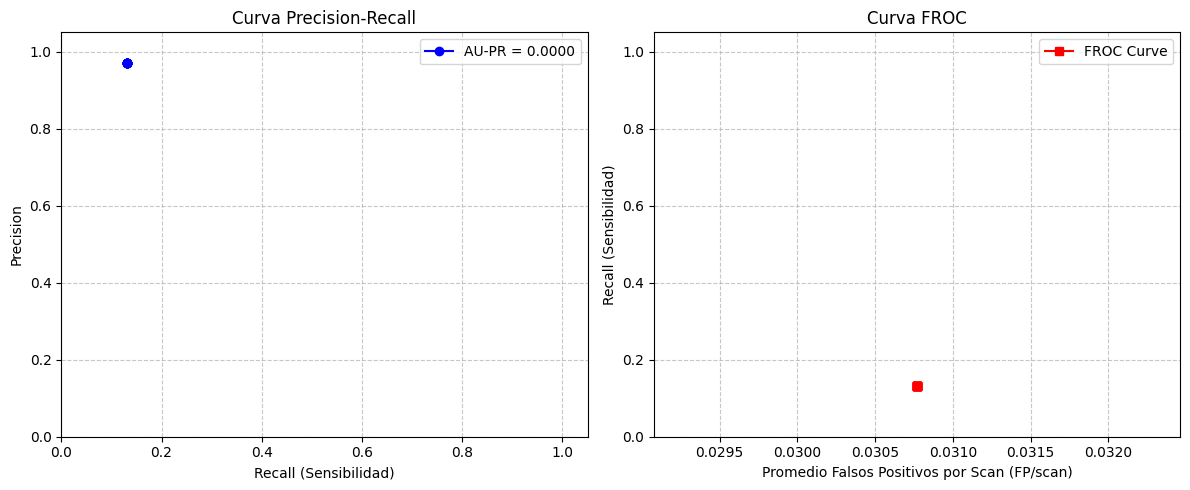


Gráficas guardadas


In [1]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from tqdm import tqdm
from skimage.measure import label

# =========================
# CONFIG
# =========================
PRED_FOLDER = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/predicts_from_201_tversky_PROB"
GT_FOLDER = "/media/PORT-DISK/Practicas/nnUNet_raw_ADNI/Dataset205_MixCMB/labelsTs"
OUTPUT_PATH = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/ANALYSIS_RESULTS_MIXTEST/D201_tversky_PROB"
os.makedirs(OUTPUT_PATH, exist_ok=True)

THRESHOLDS = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# =========================
# FUNCIONES
# =========================

def calculate_metrics(tp, fp, fn):
    """Calcula precision, recall y f1 de forma segura."""
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

def load_prob(npz_path):
    # nnU-Net guarda [canales, x, y, z]. El canal 1 suele ser la lesión.
    return np.load(npz_path)['probabilities'][1]

def match_blobs(gt_img, pred_mask):
    """
    Lógica basada en solapamiento:
    Un TP se cuenta si un blob de GT intersecta con al menos un voxel de la predicción.
    """
    labeled_gt, num_gt = label(gt_img > 0, return_num=True)
    labeled_pred, num_pred = label(pred_mask > 0, return_num=True)
    
    tp_count = 0
    used_pred_blobs = set()

    for gt_id in range(1, num_gt + 1):
        gt_blob_mask = (labeled_gt == gt_id)
        # Encontrar IDs de predicción que solapan con este blob de GT
        overlapping_pred_ids = np.unique(labeled_pred[gt_blob_mask])
        overlapping_pred_ids = overlapping_pred_ids[overlapping_pred_ids > 0]

        assigned = None
        for pid in overlapping_pred_ids:
            if pid not in used_pred_blobs:
                assigned = pid
                break
        
        if assigned is not None:
            tp_count += 1
            used_pred_blobs.add(assigned)

    fp_count = num_pred - len(used_pred_blobs)
    fn_count = num_gt - tp_count
    
    return tp_count, fp_count, fn_count

# =========================
# MAIN
# =========================

cases = sorted([f.replace(".npz", "") for f in os.listdir(PRED_FOLDER) if f.endswith(".npz")])
final_results = []

for thr in THRESHOLDS:
    print(f"\n--- Analizando Threshold: {thr} ---")
    
    subject_metrics = []
    
    for case in tqdm(cases):
        npz_path = os.path.join(PRED_FOLDER, f"{case}.npz")
        gt_path = os.path.join(GT_FOLDER, f"{case}.nii.gz")

        if not os.path.exists(gt_path):
            continue

        # Cargar datos
        prob = load_prob(npz_path)
        gt_nifti = nib.load(gt_path)
        gt_data = gt_nifti.get_fdata()
        
        # Binarizar predicción
        pred_mask = (prob > thr).astype(np.uint8)

        # Corregir transposición si las dimensiones no coinciden
        # (nnU-Net a veces exporta npz en ejes distintos al nifti original)
        if pred_mask.shape != gt_data.shape:
            pred_mask = np.transpose(pred_mask, (2, 1, 0))
            if pred_mask.shape != gt_data.shape:
                # Si sigue fallando, añadida por mí: intento de transposición alternativa
                pred_mask = np.transpose(prob, (1, 2, 0)) # Depende del preprocesado

        # Calcular matching por componentes conectadas
        tp, fp, fn = match_blobs(gt_data, pred_mask)
        
        # Métricas a nivel sujeto para este threshold
        prec, rec, f1 = calculate_metrics(tp, fp, fn)
        
        subject_metrics.append({
            'TP': tp, 'FP': fp, 'FN': fn,
            'Prec': prec, 'Rec': rec, 'F1': f1
        })

    # --- Agregación para el Threshold actual ---
    df_thr = pd.DataFrame(subject_metrics)
    
    # Micro (Suma de todo)
    total_tp = df_thr['TP'].sum()
    total_fp = df_thr['FP'].sum()
    total_fn = df_thr['FN'].sum()
    mi_prec, mi_rec, mi_f1 = calculate_metrics(total_tp, total_fp, total_fn)
    
    # Macro (Media de sujetos)
    ma_prec = df_thr['Prec'].mean()
    ma_rec = df_thr['Rec'].mean()
    ma_f1 = df_thr['F1'].mean()
    fp_per_scan = total_fp / len(cases)

    print(f"Resultados Globales (Thr {thr}):")
    print(f"TP: {total_tp} | FN: {total_fn} (Total GT: {total_tp + total_fn})")
    print(f"Recall Micro: {mi_rec:.4f} | Prec Micro: {mi_prec:.4f} | FP/scan: {fp_per_scan:.2f}")

    final_results.append({
        'threshold': thr,
        'TP_total': total_tp,
        'FP_total': total_fp,
        'FN_total': total_fn,
        'Recall_Micro': mi_rec,
        'Prec_Micro': mi_prec,
        'F1_Micro': mi_f1,
        'Recall_Macro': ma_rec,
        'Prec_Macro': ma_prec,
        'F1_Macro': ma_f1,
        'FP_per_scan': fp_per_scan
    })

# Guardar
df_final = pd.DataFrame(final_results)
df_final.to_csv(os.path.join(OUTPUT_PATH, "D800_PROB_thrs.csv"), index=False)
print(f"\nAnálisis por umbrales guardado en: {OUTPUT_PATH}")

import matplotlib.pyplot as plt
from sklearn.metrics import auc

# =========================
# CÁLCULO DE MÉTRICAS GLOBALES
# =========================

# Extraer valores para las curvas
# Es importante que los datos estén ordenados por threshold para que las curvas sigan una lógica
df_final = df_final.sort_values('threshold', ascending=False)

thresholds = df_final['threshold'].values
recalls = df_final['Recall_Micro'].values
precisions = df_final['Prec_Micro'].values
fps_per_scan = df_final['FP_per_scan'].values

# 1. Calcular AU-PR (Área bajo Precision-Recall)
# Nota: Se suele añadir el punto (1, 0) y (0, 1) para cerrar la curva si es necesario
au_pr = auc(recalls, precisions)

# 2. Calcular "Área bajo la FROC" (opcional, en un rango específico de FP)
# El FROC no tiene un "área" estándar como el AUC-ROC, pero se puede calcular
au_froc = auc(fps_per_scan, recalls)

print(f"\n--- Métricas de Curvas ---")
print(f"AU-PR: {au_pr:.4f}")
print(f"Área bajo FROC (hasta FP max): {au_froc:.4f}")

# =========================
# GENERACIÓN DE GRÁFICAS
# =========================

plt.figure(figsize=(12, 5))

# --- Gráfica 1: Precision-Recall Curve ---
plt.subplot(1, 2, 1)
plt.plot(recalls, precisions, 'b-o', label=f'AU-PR = {au_pr:.4f}')
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.ylim([0, 1.05])
plt.xlim([0, 1.05])

# --- Gráfica 2: FROC Curve ---
plt.subplot(1, 2, 2)
plt.plot(fps_per_scan, recalls, 'r-s', label='FROC Curve')
plt.xlabel('Promedio Falsos Positivos por Scan (FP/scan)')
plt.ylabel('Recall (Sensibilidad)')
plt.title('Curva FROC')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
# El eje X en FROC suele dejarse abierto según el máximo de FP obtenido
plt.ylim([0, 1.05]) 

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "D800_PROB_froc_curves.png"))
plt.show()

print("\nGráficas guardadas")

### D211 synthetic w/o clean subjects


--- Analizando Threshold: 0.01 ---


100%|██████████| 65/65 [02:13<00:00,  2.05s/it]


Resultados Globales (Thr 0.01):
TP: 128 | FN: 354 (Total GT: 482)
Recall Micro: 0.2656 | Prec Micro: 0.8258 | FP/scan: 0.42

--- Analizando Threshold: 0.05 ---


100%|██████████| 65/65 [02:24<00:00,  2.23s/it]


Resultados Globales (Thr 0.05):
TP: 120 | FN: 362 (Total GT: 482)
Recall Micro: 0.2490 | Prec Micro: 0.8333 | FP/scan: 0.37

--- Analizando Threshold: 0.1 ---


...

Resultados Globales (Thr 0.7):
TP: 112 | FN: 370 (Total GT: 482)
Recall Micro: 0.2324 | Prec Micro: 0.8615 | FP/scan: 0.28

--- Analizando Threshold: 0.8 ---


100%|██████████| 65/65 [02:26<00:00,  2.25s/it]


Resultados Globales (Thr 0.8):
TP: 110 | FN: 372 (Total GT: 482)
Recall Micro: 0.2282 | Prec Micro: 0.8594 | FP/scan: 0.28

--- Analizando Threshold: 0.9 ---


100%|██████████| 65/65 [02:25<00:00,  2.24s/it]


Resultados Globales (Thr 0.9):
TP: 105 | FN: 377 (Total GT: 482)
Recall Micro: 0.2178 | Prec Micro: 0.8537 | FP/scan: 0.28

Análisis por umbrales guardado en: /media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/ANALYSIS_RESULTS_MIXTEST/D211_PROB

--- Métricas de Curvas ---
AU-PR: 0.0404
Área bajo FROC (hasta FP max): 0.0344


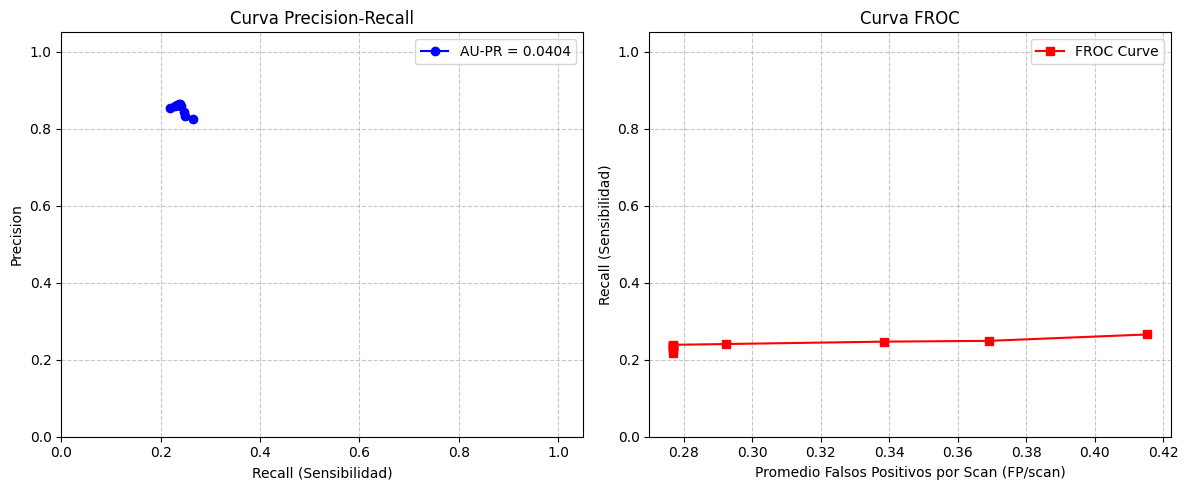


Gráficas guardadas


In [2]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from tqdm import tqdm
from skimage.measure import label

# =========================
# CONFIG
# =========================
PRED_FOLDER = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/predicts_from_211_PROB"
GT_FOLDER = "/media/PORT-DISK/Practicas/nnUNet_raw_ADNI/Dataset205_MixCMB/labelsTs"
OUTPUT_PATH = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/PREDICTS_ON_VALDO/ANALYSIS_RESULTS_MIXTEST/D211_PROB"
os.makedirs(OUTPUT_PATH, exist_ok=True)

THRESHOLDS = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# =========================
# FUNCIONES
# =========================

def calculate_metrics(tp, fp, fn):
    """Calcula precision, recall y f1 de forma segura."""
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

def load_prob(npz_path):
    # nnU-Net guarda [canales, x, y, z]. El canal 1 suele ser la lesión.
    return np.load(npz_path)['probabilities'][1]

def match_blobs(gt_img, pred_mask):
    """
    Lógica basada en solapamiento:
    Un TP se cuenta si un blob de GT intersecta con al menos un voxel de la predicción.
    """
    labeled_gt, num_gt = label(gt_img > 0, return_num=True)
    labeled_pred, num_pred = label(pred_mask > 0, return_num=True)
    
    tp_count = 0
    used_pred_blobs = set()

    for gt_id in range(1, num_gt + 1):
        gt_blob_mask = (labeled_gt == gt_id)
        # Encontrar IDs de predicción que solapan con este blob de GT
        overlapping_pred_ids = np.unique(labeled_pred[gt_blob_mask])
        overlapping_pred_ids = overlapping_pred_ids[overlapping_pred_ids > 0]

        assigned = None
        for pid in overlapping_pred_ids:
            if pid not in used_pred_blobs:
                assigned = pid
                break
        
        if assigned is not None:
            tp_count += 1
            used_pred_blobs.add(assigned)

    fp_count = num_pred - len(used_pred_blobs)
    fn_count = num_gt - tp_count
    
    return tp_count, fp_count, fn_count

# =========================
# MAIN
# =========================

cases = sorted([f.replace(".npz", "") for f in os.listdir(PRED_FOLDER) if f.endswith(".npz")])
final_results = []

for thr in THRESHOLDS:
    print(f"\n--- Analizando Threshold: {thr} ---")
    
    subject_metrics = []
    
    for case in tqdm(cases):
        npz_path = os.path.join(PRED_FOLDER, f"{case}.npz")
        gt_path = os.path.join(GT_FOLDER, f"{case}.nii.gz")

        if not os.path.exists(gt_path):
            continue

        # Cargar datos
        prob = load_prob(npz_path)
        gt_nifti = nib.load(gt_path)
        gt_data = gt_nifti.get_fdata()
        
        # Binarizar predicción
        pred_mask = (prob > thr).astype(np.uint8)

        # Corregir transposición si las dimensiones no coinciden
        # (nnU-Net a veces exporta npz en ejes distintos al nifti original)
        if pred_mask.shape != gt_data.shape:
            pred_mask = np.transpose(pred_mask, (2, 1, 0))
            if pred_mask.shape != gt_data.shape:
                # Si sigue fallando, añadida por mí: intento de transposición alternativa
                pred_mask = np.transpose(prob, (1, 2, 0)) # Depende del preprocesado

        # Calcular matching por componentes conectadas
        tp, fp, fn = match_blobs(gt_data, pred_mask)
        
        # Métricas a nivel sujeto para este threshold
        prec, rec, f1 = calculate_metrics(tp, fp, fn)
        
        subject_metrics.append({
            'TP': tp, 'FP': fp, 'FN': fn,
            'Prec': prec, 'Rec': rec, 'F1': f1
        })

    # --- Agregación para el Threshold actual ---
    df_thr = pd.DataFrame(subject_metrics)
    
    # Micro (Suma de todo)
    total_tp = df_thr['TP'].sum()
    total_fp = df_thr['FP'].sum()
    total_fn = df_thr['FN'].sum()
    mi_prec, mi_rec, mi_f1 = calculate_metrics(total_tp, total_fp, total_fn)
    
    # Macro (Media de sujetos)
    ma_prec = df_thr['Prec'].mean()
    ma_rec = df_thr['Rec'].mean()
    ma_f1 = df_thr['F1'].mean()
    fp_per_scan = total_fp / len(cases)

    print(f"Resultados Globales (Thr {thr}):")
    print(f"TP: {total_tp} | FN: {total_fn} (Total GT: {total_tp + total_fn})")
    print(f"Recall Micro: {mi_rec:.4f} | Prec Micro: {mi_prec:.4f} | FP/scan: {fp_per_scan:.2f}")

    final_results.append({
        'threshold': thr,
        'TP_total': total_tp,
        'FP_total': total_fp,
        'FN_total': total_fn,
        'Recall_Micro': mi_rec,
        'Prec_Micro': mi_prec,
        'F1_Micro': mi_f1,
        'Recall_Macro': ma_rec,
        'Prec_Macro': ma_prec,
        'F1_Macro': ma_f1,
        'FP_per_scan': fp_per_scan
    })

# Guardar
df_final = pd.DataFrame(final_results)
df_final.to_csv(os.path.join(OUTPUT_PATH, "D800_PROB_thrs.csv"), index=False)
print(f"\nAnálisis por umbrales guardado en: {OUTPUT_PATH}")

import matplotlib.pyplot as plt
from sklearn.metrics import auc

# =========================
# CÁLCULO DE MÉTRICAS GLOBALES
# =========================

# Extraer valores para las curvas
# Es importante que los datos estén ordenados por threshold para que las curvas sigan una lógica
df_final = df_final.sort_values('threshold', ascending=False)

thresholds = df_final['threshold'].values
recalls = df_final['Recall_Micro'].values
precisions = df_final['Prec_Micro'].values
fps_per_scan = df_final['FP_per_scan'].values

# 1. Calcular AU-PR (Área bajo Precision-Recall)
# Nota: Se suele añadir el punto (1, 0) y (0, 1) para cerrar la curva si es necesario
au_pr = auc(recalls, precisions)

# 2. Calcular "Área bajo la FROC" (opcional, en un rango específico de FP)
# El FROC no tiene un "área" estándar como el AUC-ROC, pero se puede calcular
au_froc = auc(fps_per_scan, recalls)

print(f"\n--- Métricas de Curvas ---")
print(f"AU-PR: {au_pr:.4f}")
print(f"Área bajo FROC (hasta FP max): {au_froc:.4f}")

# =========================
# GENERACIÓN DE GRÁFICAS
# =========================

plt.figure(figsize=(12, 5))

# --- Gráfica 1: Precision-Recall Curve ---
plt.subplot(1, 2, 1)
plt.plot(recalls, precisions, 'b-o', label=f'AU-PR = {au_pr:.4f}')
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.ylim([0, 1.05])
plt.xlim([0, 1.05])

# --- Gráfica 2: FROC Curve ---
plt.subplot(1, 2, 2)
plt.plot(fps_per_scan, recalls, 'r-s', label='FROC Curve')
plt.xlabel('Promedio Falsos Positivos por Scan (FP/scan)')
plt.ylabel('Recall (Sensibilidad)')
plt.title('Curva FROC')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
# El eje X en FROC suele dejarse abierto según el máximo de FP obtenido
plt.ylim([0, 1.05]) 

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "D800_PROB_froc_curves.png"))
plt.show()

print("\nGráficas guardadas")